<a href="https://colab.research.google.com/github/andrealopez47/goatdevice_evaluation/blob/main/temp_cabritas_blandaltman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving temperature_data_BlandAltman.csv to temperature_data_BlandAltman.csv
Bias: 0.0364
SD: 0.0822
Upper LoA (+2SD): 0.2009
Lower LoA (-2SD): -0.128


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

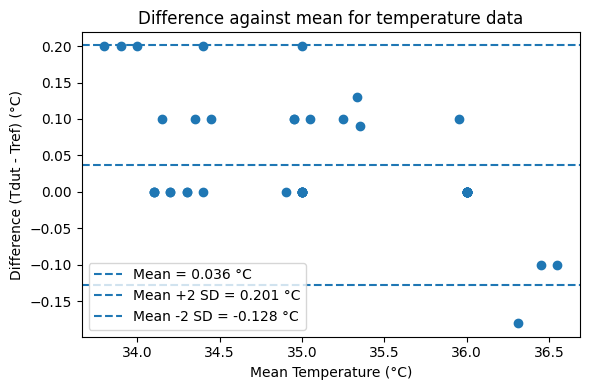

In [1]:
# =========================
# BLAND-ALTMAN con ±2 SD
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Subir archivo
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Cálculos
df["Mean"] = (df["Tref"] + df["Tebp"]) / 2
df["Difference"] = df["Tebp"] - df["Tref"]

bias = df["Difference"].mean()
sd = df["Difference"].std(ddof=1)

loa_upper = bias + 2 * sd
loa_lower = bias - 2 * sd

print("Bias:", round(bias,4))
print("SD:", round(sd,4))
print("Upper LoA (+2SD):", round(loa_upper,4))
print("Lower LoA (-2SD):", round(loa_lower,4))

# Gráfica
plt.figure(figsize=(6,4))

plt.scatter(df["Mean"], df["Difference"])

plt.axhline(bias, linestyle='--', label=f'Mean = {bias:.3f} °C')
plt.axhline(loa_upper, linestyle='--', label=f'Mean +2 SD = {loa_upper:.3f} °C')
plt.axhline(loa_lower, linestyle='--', label=f'Mean -2 SD = {loa_lower:.3f} °C')

plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Difference (Tdut - Tref) (°C)")
plt.title("Difference against mean for temperature data")

plt.legend()
plt.tight_layout()

plt.savefig("bland_altman_2SD.png", dpi=300)

# Guardar resultados
results = pd.DataFrame({
    "Metric": ["Bias", "SD", "Upper LoA (+2SD)", "Lower LoA (-2SD)"],
    "Value": [bias, sd, loa_upper, loa_lower]
})

results.to_csv("bland_altman_2SD_stats.csv", index=False)

files.download("bland_altman_2SD.png")
files.download("bland_altman_2SD_stats.csv")